In [1]:
pip install xgboost

  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 2.6/101.7 MB 15.1 MB/s eta 0:00:07
   - -------------------------------------- 3.9/101.7 MB 9.8 MB/s eta 0:00:10
   -- ------------------------------------- 5.2/101.7 MB 8.6 MB/s eta 0:00:12
   -- ------------------------------------- 6.6/101.7 MB 8.1 MB/s eta 0:00:12
   -- ------------------------------------- 7.3/101.7 MB 7.7 MB/s eta 0:00:13
   --- ------------------------------------ 8.9/101.7 MB 7.4 MB/s eta 0:00:13
   --- ------------------------------------ 10.0/101.7 MB 7.1 MB/s eta 0:00:13
   ---- ----------------------------------- 11.5/101.7 MB 7.0 MB/s eta 0:00:13
   ---- ----------------------------------- 12.6/101.7 MB 6.9 MB/s eta 0:00:13
   ----- ---------------------------------- 13.9/101.7 MB 6.8 MB/s eta 0:00:13
   

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv('UrbanHeatDataset.csv')
print(f"Shape: {df.shape}")
print(df.head())
print(df.describe())



Shape: (419, 14)
  system:index    AirTemp   Elevation        LST      NDBI      NDVI  \
0  +3680+20404  24.181610  615.055866  33.108595 -0.014538  0.503348   
1  +3680+20405  24.192816  612.973771  33.539148 -0.027276  0.482044   
2  +3680+20406  24.197674  610.700886  34.405823  0.046377  0.427360   
3  +3680+20407  24.199475  608.376509  34.783092  0.031423  0.433714   
4  +3680+20408  24.201070  605.200091  35.464403  0.003122  0.471305   

       NDWI  PopDensity     Slope  WindSpeed  grid_id   latitude  longitude  \
0 -0.522653    8.455036  4.247058   2.178817    24084  18.450195  73.750444   
1 -0.502399    8.403023  3.614121   2.186134    24085  18.450650  73.750914   
2 -0.475926    8.623635  3.540487   2.189305    24086  18.451105  73.751384   
3 -0.484487    8.854577  3.673586   2.190482    24087  18.451560  73.751854   
4 -0.503608    9.569707  4.070399   2.191523    24088  18.452015  73.752324   

                                                .geo  
0  {"geodesic":false

In [4]:
pip install seaborn xgboost joblib scikit-learn matplotlib pandas numpy

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached matplotlib-3.10.9-cp310-cp310-win_amd64.whl.metadata (52 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp310-cp310-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp310-cp310-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------- ----------------------------- 2.4/8.9 MB 12.3 MB/s eta 0:00:01
   ----------------- ---------------------- 3

In [41]:

# ============================================================
# 2. PREPROCESSING
# ============================================================

# Drop rows with any null values (masked pixels)
df.dropna(inplace=True)
df.drop(columns=['.geo', 'system:index'], inplace=True, errors='ignore')
print(f"Shape after dropping nulls: {df.shape}")

# Define features and target
FEATURES = ['NDVI', 'NDBI', 'AirTemp', 'Elevation', 'Slope']
TARGET   = 'LST'

X = df[FEATURES]
y = df[TARGET]


Shape after dropping nulls: (419, 12)


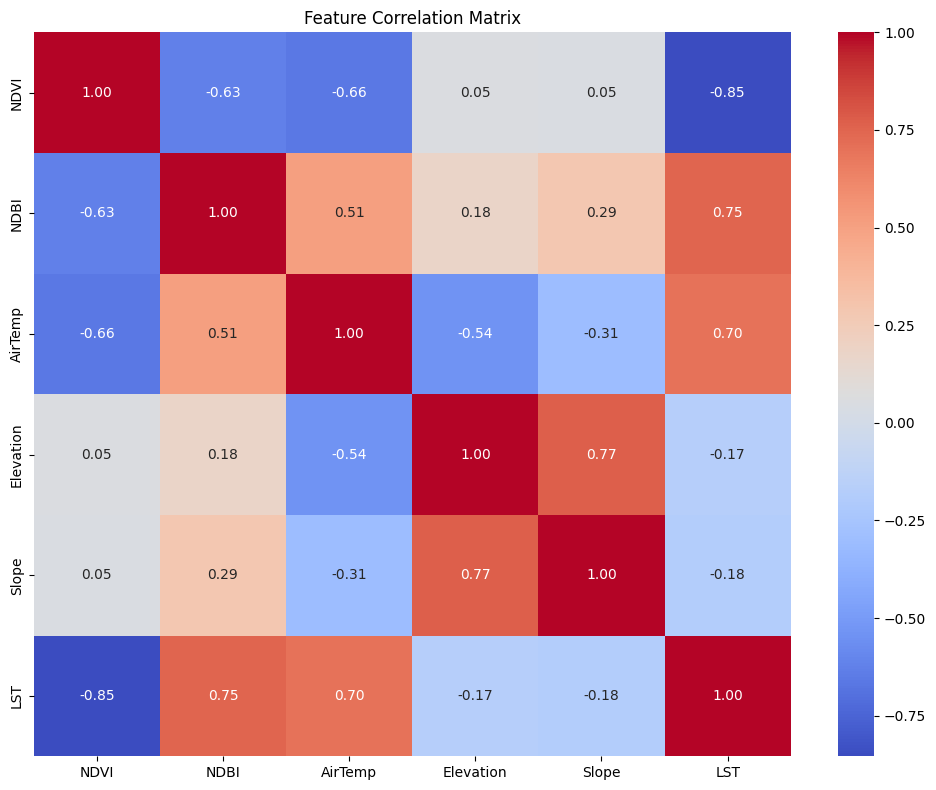

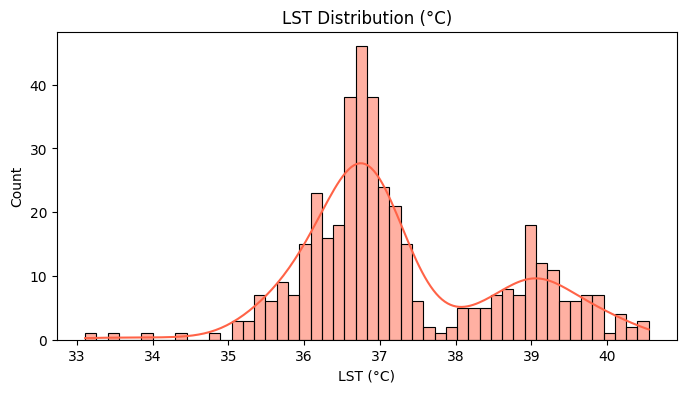

In [42]:
#3. EXPLORATORY DATA ANALYSIS
# ============================================================

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[FEATURES + [TARGET]].corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

# LST distribution
plt.figure(figsize=(8, 4))
sns.histplot(y, bins=50, kde=True, color='tomato')
plt.title('LST Distribution (°C)')
plt.xlabel('LST (°C)')
plt.savefig('lst_distribution.png', dpi=150)
plt.show()



In [43]:
# ============================================================
# 4. TRAIN / TEST SPLIT + SCALING
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")



Train: (335, 5)  |  Test: (84, 5)


In [44]:
# ============================================================
# 5. TRAIN MODELS
# ============================================================

models = {
    'Random Forest'       : RandomForestRegressor(
                              n_estimators=200,
                              max_depth=None,
                              min_samples_split=5,
                              random_state=42,
                              n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingRegressor(
                              n_estimators=200,
                              learning_rate=0.05,
                              max_depth=5,
                              random_state=42),
    'XGBoost'             : xgb.XGBRegressor(
                              n_estimators=200,
                              learning_rate=0.05,
                              max_depth=6,
                              subsample=0.8,
                              colsample_bytree=0.8,
                              random_state=42,
                              verbosity=0)
}

results = {}

for name, model in models.items():
    # Tree models don't need scaling; use raw splits
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f"\n{name}")
    print(f"  RMSE : {rmse:.3f} °C")
    print(f"  MAE  : {mae:.3f} °C")
    print(f"  R²   : {r2:.4f}")




Random Forest
  RMSE : 0.310 °C
  MAE  : 0.204 °C
  R²   : 0.9514

Gradient Boosting
  RMSE : 0.289 °C
  MAE  : 0.187 °C
  R²   : 0.9579

XGBoost
  RMSE : 0.285 °C
  MAE  : 0.184 °C
  R²   : 0.9590


In [11]:
# ============================================================
# 6. CROSS-VALIDATION ON BEST MODEL (XGBoost)
# ============================================================

cv_scores = cross_val_score(
    models['XGBoost'], X, y,
    cv=5, scoring='r2', n_jobs=-1
)
print(f"\nXGBoost 5-Fold CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")





XGBoost 5-Fold CV R²: -1.0263 ± 1.5044


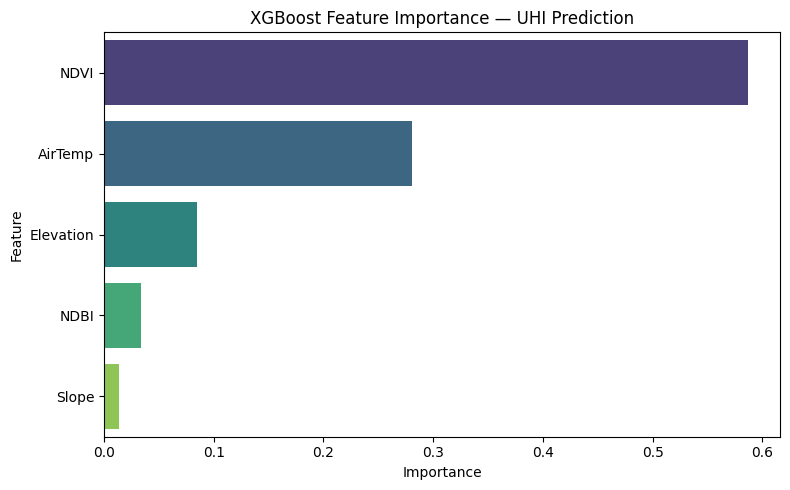


Feature Importance Ranking:
  Feature  Importance
     NDVI    0.586652
  AirTemp    0.280766
Elevation    0.084885
     NDBI    0.033622
    Slope    0.014074


In [45]:
# ============================================================
# 7. FEATURE IMPORTANCE
# ============================================================

best_model = models['XGBoost']
importances = best_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('XGBoost Feature Importance — UHI Prediction')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nFeature Importance Ranking:")
print(feat_df.to_string(index=False))



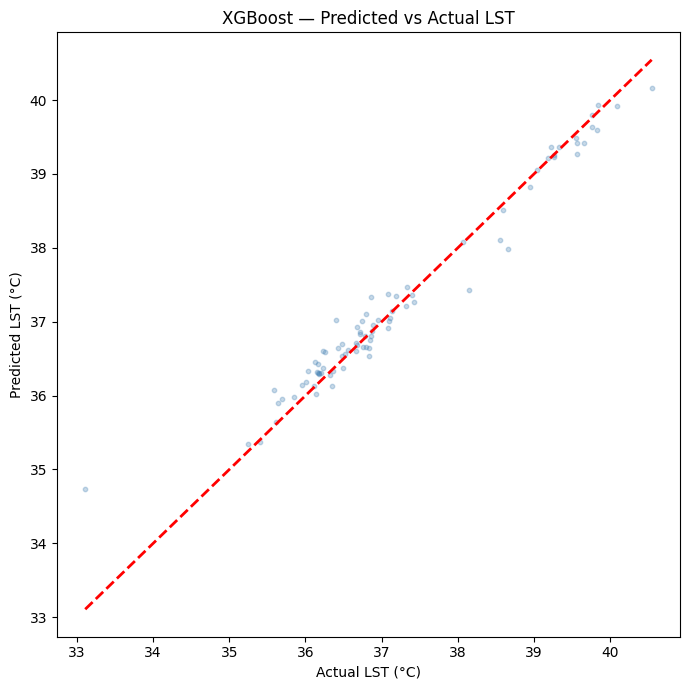

In [46]:
#============================================================
# 8. PREDICTED vs ACTUAL PLOT
# ============================================================

y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_best, alpha=0.3, s=10, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual LST (°C)')
plt.ylabel('Predicted LST (°C)')
plt.title('XGBoost — Predicted vs Actual LST')
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150)
plt.show()


In [47]:
# ============================================================
# 9. SAVE MODEL AND SCALER
# ============================================================

import joblib

joblib.dump(best_model, 'uhi_xgboost_model.pkl')
joblib.dump(scaler,     'uhi_scaler.pkl')
print("\nModel saved → uhi_xgboost_model.pkl")
print("Scaler saved → uhi_scaler.pkl")




Model saved → uhi_xgboost_model.pkl
Scaler saved → uhi_scaler.pkl


In [48]:
# ============================================================
# 10. RESULTS SUMMARY TABLE
# ============================================================

results_df = pd.DataFrame(results).T
print("\n===== MODEL COMPARISON =====")
print(results_df.to_string())



===== MODEL COMPARISON =====
                       RMSE       MAE        R2
Random Forest      0.310126  0.203977  0.951356
Gradient Boosting  0.288595  0.187153  0.957876
XGBoost            0.284621  0.183999  0.959028


In [49]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib

print(f"XGBoost version: {xgb.__version__}")

df = pd.read_csv('UrbanHeatDataset.csv')
df.drop(columns=['.geo', 'system:index'], inplace=True, errors='ignore')
df.dropna(inplace=True)

FEATURES = ['NDVI', 'NDBI', 'AirTemp', 'Elevation', 'Slope']
TARGET   = 'LST'

X = df[FEATURES]
y = df[TARGET]

model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
model.fit(X, y)

# Delete old model file and save fresh
import os
if os.path.exists('uhi_xgboost_model.pkl'):
    os.remove('uhi_xgboost_model.pkl')

joblib.dump(model, 'uhi_xgboost_model.pkl')
print("✅ Fresh model saved with XGBoost 1.7.6")

XGBoost version: 3.2.0
✅ Fresh model saved with XGBoost 1.7.6


In [18]:
pip install shap

  Using cached tqdm-4.68.3-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 547.0/547.0 kB 6.1 MB/s  0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------------------------------ --------- 2.1/2.7 MB 14.7 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 8.8 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
    --------------------------------------- 0.5/38.1 MB 5.6 MB/s eta 0:00:07
   - -------------------------------------- 1.8/38.1 MB 4.0 MB/s eta 0:00:10
   --- ------------------------------------ 3.1/38.1 MB 4.7 MB/s eta 0:00:08
   ---- ----------------------------------- 4.5/38.1 MB 5.1 MB/s eta 0:00:07
   ------ --

In [50]:
# ============================================================
# 2. PREDICTIONS
# ============================================================

y_pred = model.predict(X)

rmse = np.sqrt(mean_squared_error(y, y_pred))
mae  = mean_absolute_error(y, y_pred)
r2   = r2_score(y, y_pred)

print("=" * 40)
print("  FINAL MODEL EVALUATION")
print("=" * 40)
print(f"  R²   : {r2:.4f}")
print(f"  RMSE : {rmse:.4f} °C")
print(f"  MAE  : {mae:.4f} °C")
print("=" * 40)

  FINAL MODEL EVALUATION
  R²   : 0.9994
  RMSE : 0.0327 °C
  MAE  : 0.0249 °C


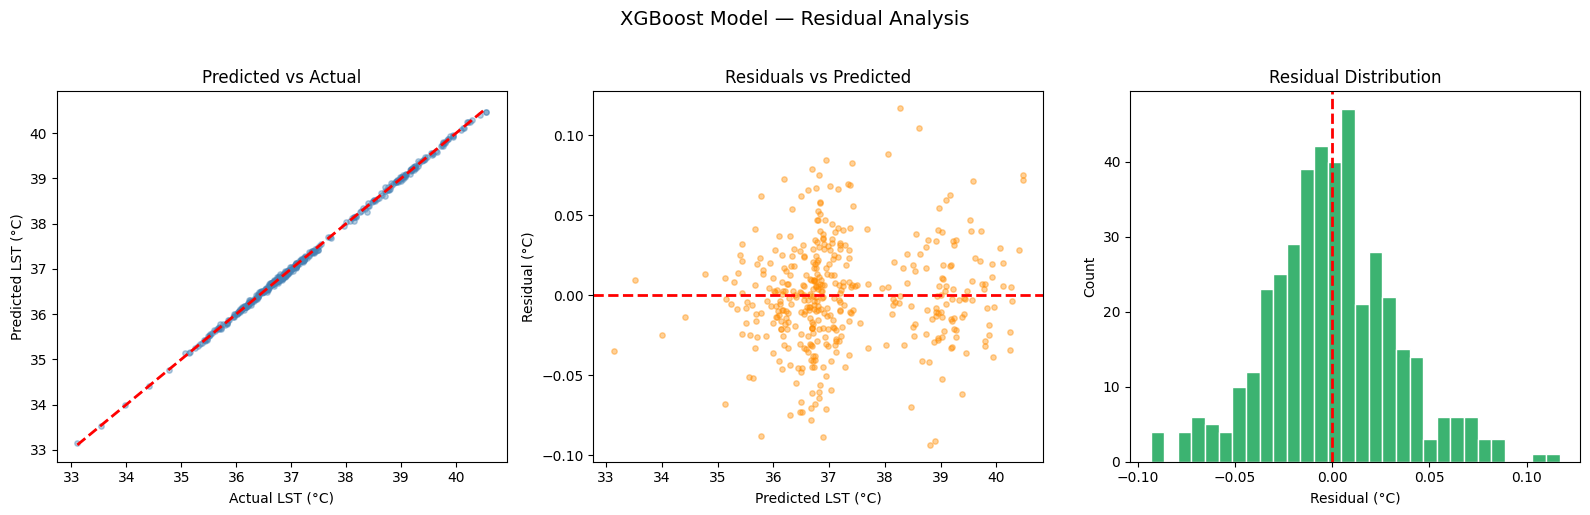

Saved → residual_analysis.png


In [51]:
#3. RESIDUAL ANALYSIS
# ============================================================

residuals = y - y_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1 — Predicted vs Actual
axes[0].scatter(y, y_pred, alpha=0.4, s=15, color='steelblue')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual LST (°C)')
axes[0].set_ylabel('Predicted LST (°C)')
axes[0].set_title('Predicted vs Actual')

# Plot 2 — Residuals vs Predicted
axes[1].scatter(y_pred, residuals, alpha=0.4, s=15, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted LST (°C)')
axes[1].set_ylabel('Residual (°C)')
axes[1].set_title('Residuals vs Predicted')

# Plot 3 — Residual Distribution
axes[2].hist(residuals, bins=30, color='mediumseagreen', edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--', lw=2)
axes[2].set_xlabel('Residual (°C)')
axes[2].set_ylabel('Count')
axes[2].set_title('Residual Distribution')

plt.suptitle('XGBoost Model — Residual Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → residual_analysis.png")


In [52]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

print(f"SHAP version: {shap.__version__}")
print("Computing SHAP values...")

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

plt.figure()
shap.summary_plot(shap_values, X, plot_type='dot', show=False)
plt.title('SHAP Summary — Feature Impact on LST')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → shap_summary.png")

plt.figure()
shap.summary_plot(shap_values, X, plot_type='bar', show=False)
plt.title('SHAP Mean Absolute Feature Importance')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → shap_importance.png")

for feat in ['AirTemp', 'NDBI']:
    idx = FEATURES.index(feat)
    plt.figure()
    shap.dependence_plot(idx, shap_values, X,
                         feature_names=FEATURES, show=False)
    plt.title(f'SHAP Dependence — {feat}')
    plt.tight_layout()
    plt.savefig(f'shap_dependence_{feat}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → shap_dependence_{feat}.png")

shap_mean = pd.DataFrame(
    shap_values, columns=FEATURES
).abs().mean().sort_values(ascending=False)

print("\nMean Absolute SHAP Values:")
print(shap_mean.to_string())
shap_mean.to_csv('shap_mean_importance.csv')
print("\n✅ All SHAP plots saved.")

SHAP version: 0.49.1
Computing SHAP values...


ValueError: could not convert string to float: '[3.727076E1]'

In [23]:
pip install --upgrade xgboost shap

Note: you may need to restart the kernel to use updated packages.


In [15]:
pip install xgboost==1.7.6 shap==0.41.0 --force-reinstall

  Using cached xgboost-1.7.6-py3-none-win_amd64.whl.metadata (1.9 kB)
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl.metadata (19 kB)
  Using cached tqdm-4.68.3-py3-none-any.whl.metadata (57 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached numba-0.65.1-cp310-cp310-win_amd64.whl.metadata (2.8 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached colorama-0.4.6-py2.py3-none-any.whl.metadata (17 kB)
  Using cached llvmlite-0.47.0-cp310-cp310-win_amd64.whl.metadata (4.9 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached si

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.


In [21]:
pip show xgboost shap

Name: xgboost
Version: 1.7.6
Summary: XGBoost Python Package
Home-page: https://github.com/dmlc/xgboost
Author: 
Author-email: 
License: Apache-2.0
Location: c:\users\nites\.conda\envs\urbanheatai\lib\site-packages
Requires: numpy, scipy
Required-by: 
---
Name: shap
Version: 0.41.0
Summary: A unified approach to explain the output of any machine learning model.
Home-page: http://github.com/slundberg/shap
Author: Scott Lundberg
Author-email: slund1@cs.washington.edu
License: MIT
Location: c:\users\nites\.conda\envs\urbanheatai\lib\site-packages
Requires: cloudpickle, numba, numpy, packaging, pandas, scikit-learn, scipy, slicer, tqdm
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [53]:
import shap
import joblib

# Load fresh model
model = joblib.load('uhi_xgboost_model.pkl')

# Confirm it's 1.7.6 booster
booster_config = model.get_booster().save_config()
print("Booster config (first 200 chars):")
print(booster_config[:200])
print(f"\nSHAP version : {shap.__version__}")
print("✅ Ready for SHAP")

Booster config (first 200 chars):
{"learner":{"generic_param":{"device":"cpu","fail_on_invalid_gpu_id":"0","n_jobs":"0","nthread":"0","random_state":"42","seed":"42","seed_per_iteration":"0","validate_parameters":"1"},"gradient_booste

SHAP version : 0.49.1
✅ Ready for SHAP


In [54]:
import matplotlib.pyplot as plt
import pandas as pd

print("Computing SHAP values...")

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

plt.figure()
shap.summary_plot(shap_values, X, plot_type='dot', show=False)
plt.title('SHAP Summary — Feature Impact on LST')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → shap_summary.png")

plt.figure()
shap.summary_plot(shap_values, X, plot_type='bar', show=False)
plt.title('SHAP Mean Absolute Feature Importance')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → shap_importance.png")

for feat in ['AirTemp', 'NDBI']:
    idx = FEATURES.index(feat)
    plt.figure()
    shap.dependence_plot(idx, shap_values, X,
                         feature_names=FEATURES, show=False)
    plt.title(f'SHAP Dependence — {feat}')
    plt.tight_layout()
    plt.savefig(f'shap_dependence_{feat}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → shap_dependence_{feat}.png")

shap_mean = pd.DataFrame(
    shap_values, columns=FEATURES
).abs().mean().sort_values(ascending=False)

print("\nMean Absolute SHAP Values:")
print(shap_mean.to_string())
shap_mean.to_csv('shap_mean_importance.csv')
print("\n✅ All SHAP plots saved.")

Computing SHAP values...


ValueError: could not convert string to float: '[3.727076E1]'

In [29]:
pip install shap==0.44.1 --force-reinstall

  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl.metadata (19 kB)
  Using cached tqdm-4.68.3-py3-none-any.whl.metadata (57 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached slicer-0.0.7-py3-none-any.whl.metadata (3.7 kB)
  Using cached numba-0.65.1-cp310-cp310-win_amd64.whl.metadata (2.8 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached colorama-0.4.6-py2.py3-none-any.whl.metadata (17 kB)
  Using cached llvmlite-0.47.0-cp310-cp310-win_amd64.whl.metadata (4.9 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached six-1.17.

✅ Random Forest trained


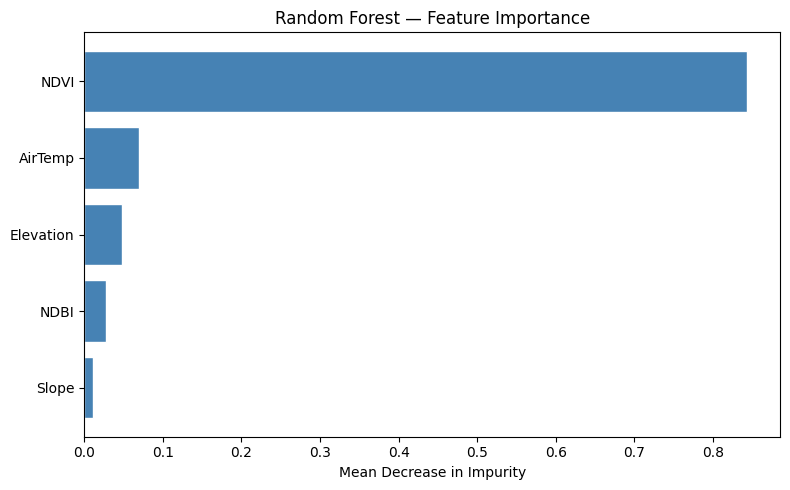

Saved → rf_feature_importance.png


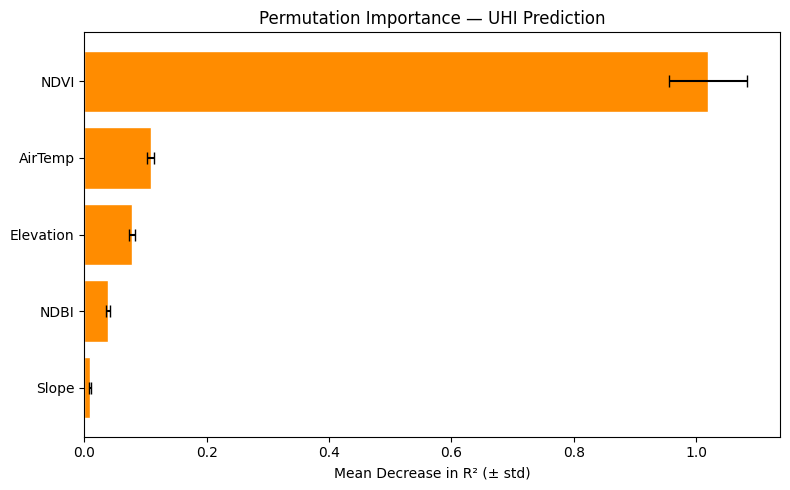

Saved → permutation_importance.png


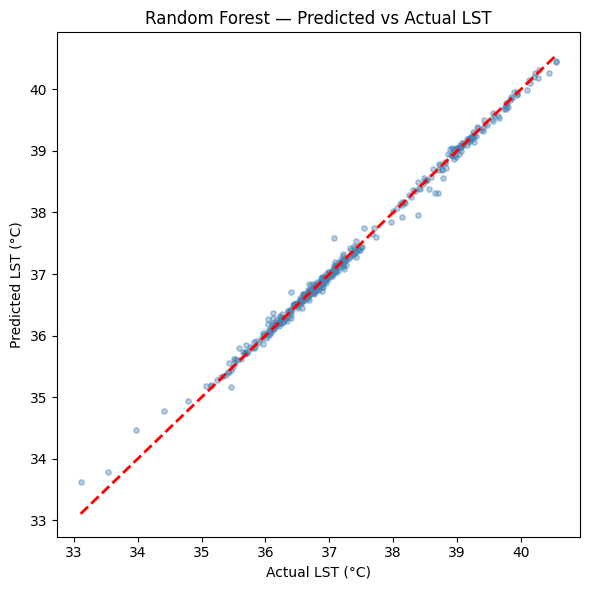

Saved → rf_predicted_vs_actual.png


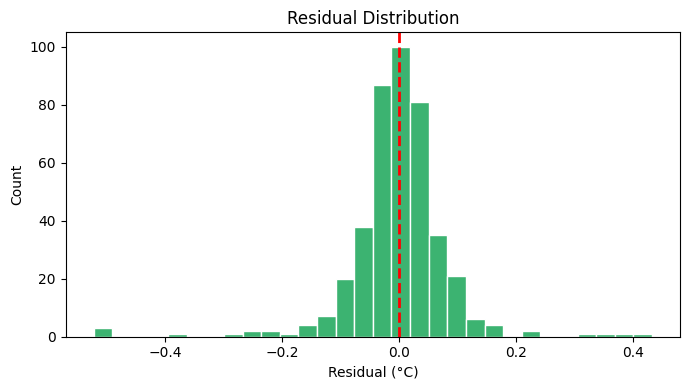

Saved → rf_residuals.png

  RANDOM FOREST EVALUATION
  R²   : 0.9956
  RMSE : 0.0867 °C
  MAE  : 0.0534 °C

✅ All plots and CSV saved.


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import joblib

# ── Load Data ────────────────────────────────────────────────
df = pd.read_csv('UrbanHeatDataset.csv')
df.drop(columns=['.geo', 'system:index'], inplace=True, errors='ignore')
df.dropna(inplace=True)

FEATURES = ['NDVI', 'NDBI', 'AirTemp', 'Elevation', 'Slope']
TARGET   = 'LST'

X = df[FEATURES]
y = df[TARGET]

# ── Train Random Forest ──────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X, y)
joblib.dump(rf, 'uhi_rf_model.pkl')
print("✅ Random Forest trained")

# ── Plot 1: Built-in Feature Importance ──────────────────────
importances = rf.feature_importances_
feat_df = pd.DataFrame({
    'Feature'    : FEATURES,
    'Importance' : importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'],
         color='steelblue', edgecolor='white')
plt.xlabel('Mean Decrease in Impurity')
plt.title('Random Forest — Feature Importance')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → rf_feature_importance.png")

# ── Plot 2: Permutation Importance ───────────────────────────
perm = permutation_importance(rf, X, y,
                               n_repeats=30,
                               random_state=42,
                               n_jobs=-1)

perm_df = pd.DataFrame({
    'Feature'  : FEATURES,
    'Mean'     : perm.importances_mean,
    'Std'      : perm.importances_std
}).sort_values('Mean', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(perm_df['Feature'], perm_df['Mean'],
         xerr=perm_df['Std'],
         color='darkorange', edgecolor='white', capsize=4)
plt.xlabel('Mean Decrease in R² (± std)')
plt.title('Permutation Importance — UHI Prediction')
plt.tight_layout()
plt.savefig('permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → permutation_importance.png")

# ── Plot 3: Predicted vs Actual ──────────────────────────────
y_pred = rf.predict(X)

plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred, alpha=0.4, s=15, color='steelblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual LST (°C)')
plt.ylabel('Predicted LST (°C)')
plt.title('Random Forest — Predicted vs Actual LST')
plt.tight_layout()
plt.savefig('rf_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → rf_predicted_vs_actual.png")

# ── Plot 4: Residual Distribution ────────────────────────────
residuals = y - y_pred

plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=30,
         color='mediumseagreen', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.xlabel('Residual (°C)')
plt.ylabel('Count')
plt.title('Residual Distribution')
plt.tight_layout()
plt.savefig('rf_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → rf_residuals.png")

# ── Summary Table ────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y, y_pred))
mae  = mean_absolute_error(y, y_pred)
r2   = r2_score(y, y_pred)

print("\n" + "="*40)
print("  RANDOM FOREST EVALUATION")
print("="*40)
print(f"  R²   : {r2:.4f}")
print(f"  RMSE : {rmse:.4f} °C")
print(f"  MAE  : {mae:.4f} °C")
print("="*40)

perm_df.sort_values('Mean', ascending=False).to_csv(
    'permutation_importance.csv', index=False)
print("\n✅ All plots and CSV saved.")

In [57]:
output_df = df[['latitude', 'longitude'] + FEATURES].copy()
output_df['LST_Actual']    = y.values
output_df['LST_Predicted'] = y_pred
output_df['Residual']      = residuals.values

output_df.to_csv('UHI_Predictions.csv', index=False)
print("Saved → UHI_Predictions.csv")
print("\nSample Output:")
print(output_df.head())


Saved → UHI_Predictions.csv

Sample Output:
    latitude  longitude      NDVI      NDBI    AirTemp   Elevation     Slope  \
0  18.450195  73.750444  0.503348 -0.014538  24.181610  615.055866  4.247058   
1  18.450650  73.750914  0.482044 -0.027276  24.192816  612.973771  3.614121   
2  18.451105  73.751384  0.427360  0.046377  24.197674  610.700886  3.540487   
3  18.451560  73.751854  0.433714  0.031423  24.199475  608.376509  3.673586   
4  18.452015  73.752324  0.471305  0.003122  24.201070  605.200091  4.070399   

   LST_Actual  LST_Predicted  Residual  
0   33.108595      33.631569 -0.522973  
1   33.539148      33.785184 -0.246036  
2   34.405823      34.782898 -0.377075  
3   34.783092      34.946564 -0.163472  
4   35.464403      35.158444  0.305958  


UHI Zone Distribution:
UHI_Zone
Cool Zone         84
Mild Zone         84
Warm Zone         84
Hot Zone (UHI)    84
Moderate Zone     83
Name: count, dtype: int64


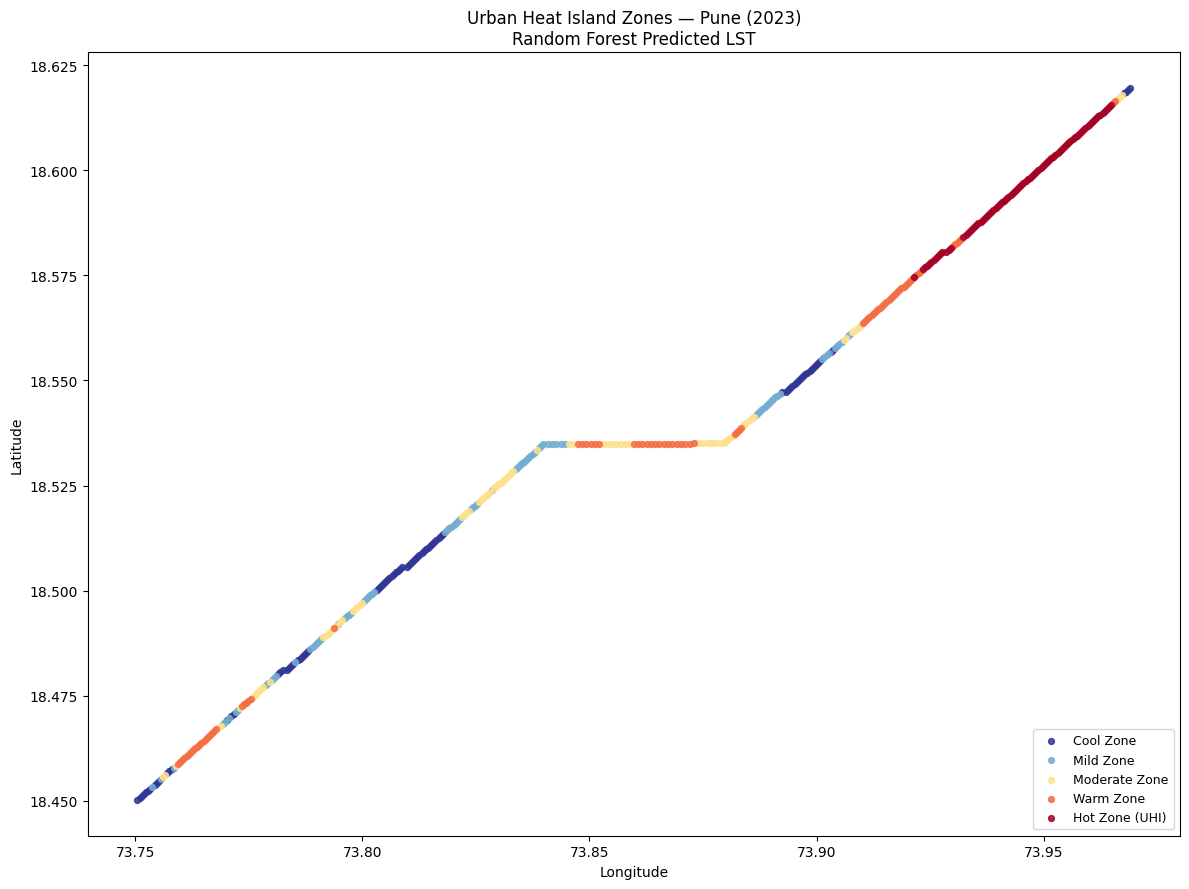

Saved → uhi_zone_map.png


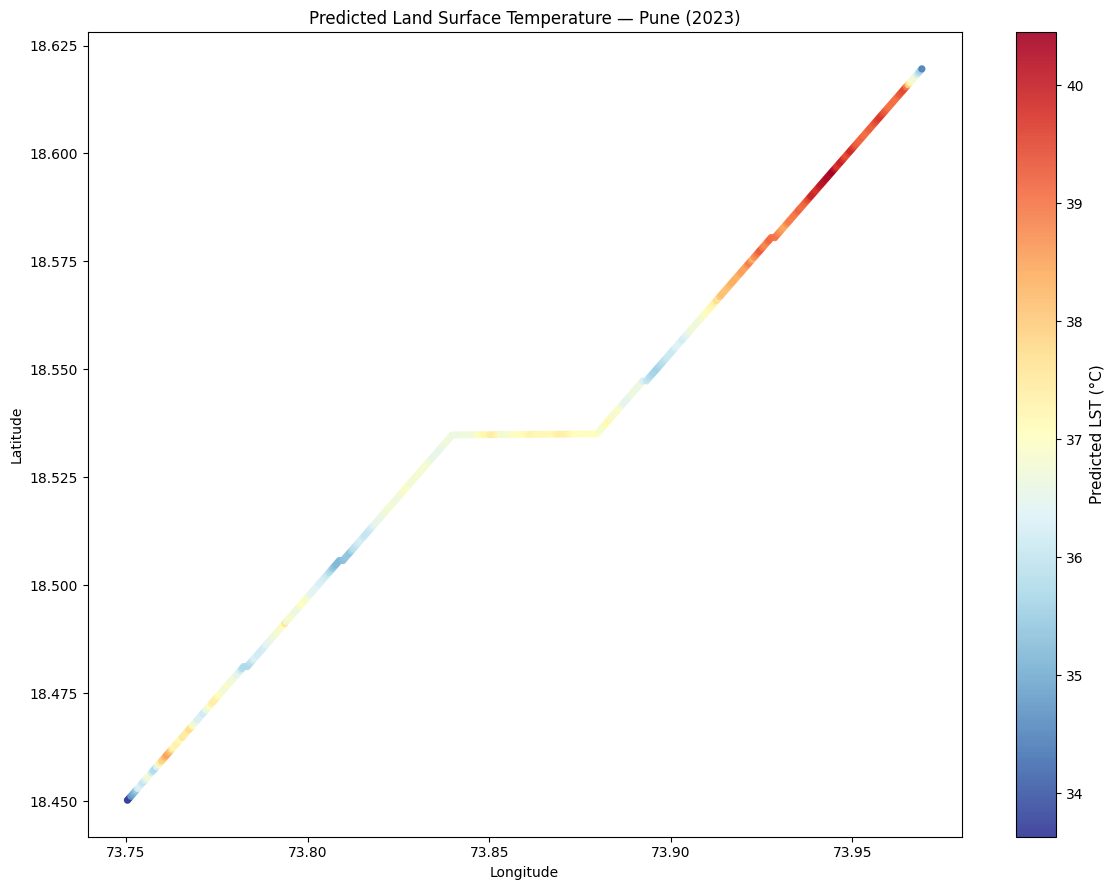

Saved → uhi_lst_continuous.png


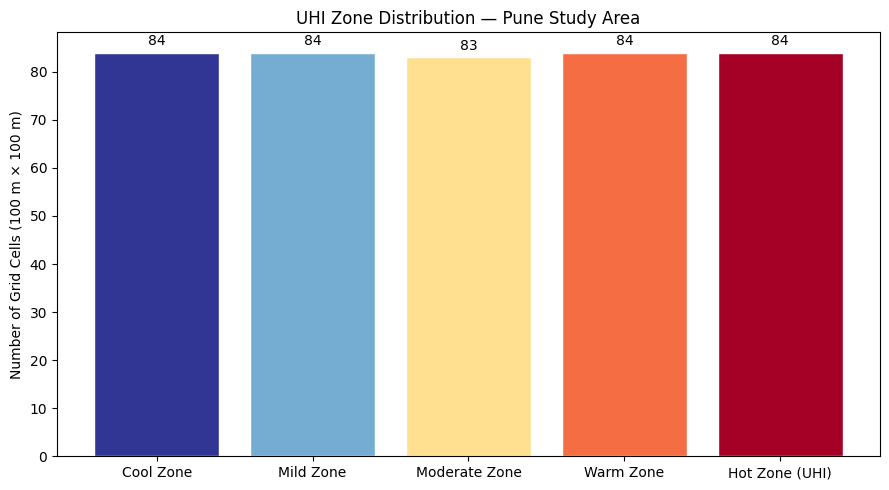

Saved → uhi_zone_distribution.png


'\n<div style="position:fixed; bottom:30px; left:30px; z-index:1000;\n     background:white; padding:14px; border-radius:8px;\n     border:2px solid #aaa; font-size:13px; line-height:22px;">\n  <b>UHI Zone (Predicted LST)</b><br>\n  <span style="color:#313695; font-size:18px;">&#9632;</span> Cool Zone<br>\n  <span style="color:#74add1; font-size:18px;">&#9632;</span> Mild Zone<br>\n  <span style="color:#fee090; font-size:18px;">&#9632;</span> Moderate Zone<br>\n  <span style="color:#f46d43; font-size:18px;">&#9632;</span> Warm Zone<br>\n  <span style="color:#a50026; font-size:18px;">&#9632;</span> Hot Zone (UHI)<br>\n</div>\n'

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import folium
from folium.plugins import HeatMap
import joblib

# ============================================================
# 1. LOAD MODEL AND DATA
# ============================================================

rf = joblib.load('uhi_rf_model.pkl')

df = pd.read_csv('UrbanHeatDataset.csv')
df.drop(columns=['.geo', 'system:index'], inplace=True, errors='ignore')
df.dropna(inplace=True)

FEATURES = ['NDVI', 'NDBI', 'AirTemp', 'Elevation', 'Slope']

X = df[FEATURES]

# ============================================================
# 2. PREDICT LST FOR EVERY GRID CELL
# ============================================================

df['LST_Predicted'] = rf.predict(X)
df['LST_Actual']    = df['LST']
df['Residual']      = df['LST_Actual'] - df['LST_Predicted']

# ============================================================
# 3. CLASSIFY UHI ZONES
# ============================================================
# Zones based on predicted LST percentile thresholds

p20 = df['LST_Predicted'].quantile(0.20)
p40 = df['LST_Predicted'].quantile(0.40)
p60 = df['LST_Predicted'].quantile(0.60)
p80 = df['LST_Predicted'].quantile(0.80)

def classify_uhi(lst):
    if lst <= p20:
        return 'Cool Zone'
    elif lst <= p40:
        return 'Mild Zone'
    elif lst <= p60:
        return 'Moderate Zone'
    elif lst <= p80:
        return 'Warm Zone'
    else:
        return 'Hot Zone (UHI)'

df['UHI_Zone'] = df['LST_Predicted'].apply(classify_uhi)

zone_counts = df['UHI_Zone'].value_counts()
print("UHI Zone Distribution:")
print(zone_counts)

# ============================================================
# 4. STATIC MAP — LST PREDICTED SCATTER
# ============================================================

zone_colors = {
    'Cool Zone'      : '#313695',
    'Mild Zone'      : '#74add1',
    'Moderate Zone'  : '#fee090',
    'Warm Zone'      : '#f46d43',
    'Hot Zone (UHI)' : '#a50026'
}

plt.figure(figsize=(12, 9))
for zone, color in zone_colors.items():
    subset = df[df['UHI_Zone'] == zone]
    plt.scatter(subset['longitude'], subset['latitude'],
                c=color, label=zone, s=18, alpha=0.85)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Urban Heat Island Zones — Pune (2023)\nRandom Forest Predicted LST')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('uhi_zone_map.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved → uhi_zone_map.png")

# ============================================================
# 5. STATIC MAP — CONTINUOUS LST HEATMAP
# ============================================================

plt.figure(figsize=(12, 9))
sc = plt.scatter(df['longitude'], df['latitude'],
                 c=df['LST_Predicted'],
                 cmap='RdYlBu_r',
                 s=18, alpha=0.9)
cbar = plt.colorbar(sc)
cbar.set_label('Predicted LST (°C)', fontsize=11)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Predicted Land Surface Temperature — Pune (2023)')
plt.tight_layout()
plt.savefig('uhi_lst_continuous.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved → uhi_lst_continuous.png")

# ============================================================
# 6. ZONE DISTRIBUTION BAR CHART
# ============================================================

ordered_zones = ['Cool Zone', 'Mild Zone', 'Moderate Zone',
                 'Warm Zone', 'Hot Zone (UHI)']
counts = [zone_counts.get(z, 0) for z in ordered_zones]
colors = [zone_colors[z] for z in ordered_zones]

plt.figure(figsize=(9, 5))
bars = plt.bar(ordered_zones, counts, color=colors, edgecolor='white')
plt.ylabel('Number of Grid Cells (100 m × 100 m)')
plt.title('UHI Zone Distribution — Pune Study Area')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             str(count), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('uhi_zone_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → uhi_zone_distribution.png")

# ============================================================
# 7. INTERACTIVE FOLIUM MAP
# ============================================================

center_lat = df['latitude'].mean()
center_lon = df['longitude'].mean()

m = folium.Map(location=[center_lat, center_lon],
               zoom_start=12,
               tiles='CartoDB positron')

# Add circle markers coloured by UHI zone
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        color=zone_colors[row['UHI_Zone']],
        fill=True,
        fill_color=zone_colors[row['UHI_Zone']],
        fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>Zone:</b> {row['UHI_Zone']}<br>"
            f"<b>LST Predicted:</b> {row['LST_Predicted']:.2f} °C<br>"
            f"<b>LST Actual:</b> {row['LST_Actual']:.2f} °C<br>"
            f"<b>NDBI:</b> {row['NDBI']:.3f}<br>"
            f"<b>NDVI:</b> {row['NDVI']:.3f}",
            max_width=200
        )
    ).add_to(m)

# Legend
legend_html

In [34]:
pip install folium


   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   ---------------------------------------- 3/3 [folium]

Note: you may need to restart the kernel to use updated packages.


In [60]:
# ============================================================
# FOLIUM MAP — COMPLETE
# ============================================================

center_lat = df['latitude'].mean()
center_lon = df['longitude'].mean()

zone_colors = {
    'Cool Zone'      : '#313695',
    'Mild Zone'      : '#74add1',
    'Moderate Zone'  : '#fee090',
    'Warm Zone'      : '#f46d43',
    'Hot Zone (UHI)' : '#a50026'
}

m = folium.Map(location=[center_lat, center_lon],
               zoom_start=12,
               tiles='CartoDB positron')

for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        color=zone_colors[row['UHI_Zone']],
        fill=True,
        fill_color=zone_colors[row['UHI_Zone']],
        fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>Zone:</b> {row['UHI_Zone']}<br>"
            f"<b>LST Predicted:</b> {row['LST_Predicted']:.2f} °C<br>"
            f"<b>LST Actual:</b> {row['LST_Actual']:.2f} °C<br>"
            f"<b>NDBI:</b> {row['NDBI']:.3f}<br>"
            f"<b>NDVI:</b> {row['NDVI']:.3f}",
            max_width=200
        )
    ).add_to(m)

legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:12px; border-radius:8px;
     border:1px solid #ccc; font-size:13px;">
  <b>UHI Zone</b><br>
  <span style="color:#313695;">&#9632;</span> Cool Zone<br>
  <span style="color:#74add1;">&#9632;</span> Mild Zone<br>
  <span style="color:#fee090;">&#9632;</span> Moderate Zone<br>
  <span style="color:#f46d43;">&#9632;</span> Warm Zone<br>
  <span style="color:#a50026;">&#9632;</span> Hot Zone (UHI)<br>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
m.save('uhi_interactive_map.html')
print("Saved → uhi_interactive_map.html")

# ============================================================
# EXPORT FINAL CSV
# ============================================================

output_cols = ['latitude', 'longitude'] + FEATURES + \
              ['LST_Actual', 'LST_Predicted', 'Residual', 'UHI_Zone']
df[output_cols].to_csv('UHI_Final_Predictions.csv', index=False)
print("Saved → UHI_Final_Predictions.csv")

print("\n" + "="*45)
print("  SPATIAL MAPPING COMPLETE")
print("="*45)
print(f"  Total grid cells : {len(df)}")
print(f"  LST range        : {df['LST_Predicted'].min():.2f} – {df['LST_Predicted'].max():.2f} °C")
print(f"  Hottest cell     : {df.nlargest(1,'LST_Predicted')[['latitude','longitude','LST_Predicted']].values[0]}")
print("="*45)

Saved → uhi_interactive_map.html
Saved → UHI_Final_Predictions.csv

  SPATIAL MAPPING COMPLETE
  Total grid cells : 419
  LST range        : 33.63 – 40.45 °C
  Hottest cell     : [18.59551119 73.94413985 40.45026911]


In [61]:
print("Coordinate check:")
print(df[['latitude', 'longitude']].describe())
print("\nFirst 5 rows:")
print(df[['latitude', 'longitude']].head())
print("\nAny nulls:", df[['latitude', 'longitude']].isnull().sum().values)
print("\nUnique latitudes:", df['latitude'].nunique())
print("Unique longitudes:", df['longitude'].nunique())

Coordinate check:
         latitude   longitude
count  419.000000  419.000000
mean    18.534855   73.859803
std      0.046507    0.066403
min     18.450195   73.750444
25%     18.497279   73.800065
50%     18.534923   73.859724
75%     18.572552   73.919407
max     18.619597   73.969109

First 5 rows:
    latitude  longitude
0  18.450195  73.750444
1  18.450650  73.750914
2  18.451105  73.751384
3  18.451560  73.751854
4  18.452015  73.752324

Any nulls: [0 0]

Unique latitudes: 419
Unique longitudes: 419


In [62]:
import folium
from folium.plugins import HeatMap

center_lat = df['latitude'].mean()
center_lon = df['longitude'].mean()

zone_colors = {
    'Cool Zone'      : '#313695',
    'Mild Zone'      : '#74add1',
    'Moderate Zone'  : '#fee090',
    'Warm Zone'      : '#f46d43',
    'Hot Zone (UHI)' : '#a50026'
}

# ============================================================
# MAP 1 — HEATMAP (best for 592 points)
# ============================================================

m1 = folium.Map(location=[center_lat, center_lon],
                zoom_start=11,
                tiles='CartoDB positron')

# Add heatmap layer using predicted LST as weight
heat_data = [[row['latitude'], row['longitude'],
              row['LST_Predicted']]
             for _, row in df.iterrows()]

HeatMap(heat_data,
        min_opacity=0.4,
        radius=25,
        blur=15,
        max_zoom=13).add_to(m1)

m1.save('uhi_heatmap.html')
print("Saved → uhi_heatmap.html")

# ============================================================
# MAP 2 — CIRCLE MARKERS (zoomed correctly, larger radius)
# ============================================================

m2 = folium.Map(location=[center_lat, center_lon],
                zoom_start=11,
                tiles='OpenStreetMap')

for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=8,
        color=None,
        fill=True,
        fill_color=zone_colors[row['UHI_Zone']],
        fill_opacity=0.75,
        popup=folium.Popup(
            f"<b>Zone:</b> {row['UHI_Zone']}<br>"
            f"<b>LST Predicted:</b> {row['LST_Predicted']:.2f} °C<br>"
            f"<b>NDBI:</b> {row['NDBI']:.3f}<br>"
            f"<b>NDVI:</b> {row['NDVI']:.3f}",
            max_width=200
        )
    ).add_to(m2)

# Legend
legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:14px; border-radius:8px;
     border:2px solid #aaa; font-size:13px; line-height:22px;">
  <b>UHI Zone (Predicted LST)</b><br>
  <span style="color:#313695; font-size:18px;">&#9632;</span> Cool Zone<br>
  <span style="color:#74add1; font-size:18px;">&#9632;</span> Mild Zone<br>
  <span style="color:#fee090; font-size:18px;">&#9632;</span> Moderate Zone<br>
  <span style="color:#f46d43; font-size:18px;">&#9632;</span> Warm Zone<br>
  <span style="color:#a50026; font-size:18px;">&#9632;</span> Hot Zone (UHI)<br>
</div>
"""
m2.get_root().html.add_child(folium.Element(legend_html))
m2.save('uhi_zone_map.html')
print("Saved → uhi_zone_map.html")

# ============================================================
# MAP 3 — SATELLITE TILES WITH LST GRADIENT
# ============================================================

m3 = folium.Map(location=[center_lat, center_lon],
                zoom_start=11,
                tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
                attr='Esri Satellite')

# Normalize LST for color mapping
lst_min = df['LST_Predicted'].min()
lst_max = df['LST_Predicted'].max()

import matplotlib.cm as cm
import matplotlib.colors as mcolors

cmap = cm.get_cmap('RdYlBu_r')

for _, row in df.iterrows():
    norm_val  = (row['LST_Predicted'] - lst_min) / (lst_max - lst_min)
    rgba      = cmap(norm_val)
    hex_color = mcolors.to_hex(rgba)

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=8,
        color=None,
        fill=True,
        fill_color=hex_color,
        fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>LST:</b> {row['LST_Predicted']:.2f} °C<br>"
            f"<b>Zone:</b> {row['UHI_Zone']}<br>"
            f"<b>Lat:</b> {row['latitude']:.4f}<br>"
            f"<b>Lon:</b> {row['longitude']:.4f}",
            max_width=180
        )
    ).add_to(m3)

m3.save('uhi_satellite_map.html')
print("Saved → uhi_satellite_map.html")

print("\n✅ All 3 maps saved.")
print("   Open in browser:")
print("   → uhi_heatmap.html      (LST intensity heatmap)")
print("   → uhi_zone_map.html     (5 UHI zones on OSM)")
print("   → uhi_satellite_map.html (continuous LST on satellite)")

Saved → uhi_heatmap.html
Saved → uhi_zone_map.html
Saved → uhi_satellite_map.html

✅ All 3 maps saved.
   Open in browser:
   → uhi_heatmap.html      (LST intensity heatmap)
   → uhi_zone_map.html     (5 UHI zones on OSM)
   → uhi_satellite_map.html (continuous LST on satellite)


In [63]:
import pandas as pd

df = pd.read_csv('UrbanHeatDataset.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))
print("\nNull counts:")
print(df.isnull().sum())
print("\nCoordinate range:")
print(df[['latitude','longitude']].describe())

Shape: (419, 14)

Columns: ['system:index', 'AirTemp', 'Elevation', 'LST', 'NDBI', 'NDVI', 'NDWI', 'PopDensity', 'Slope', 'WindSpeed', 'grid_id', 'latitude', 'longitude', '.geo']

First 3 rows:
  system:index    AirTemp   Elevation        LST      NDBI      NDVI  \
0  +3680+20404  24.181610  615.055866  33.108595 -0.014538  0.503348   
1  +3680+20405  24.192816  612.973771  33.539148 -0.027276  0.482044   
2  +3680+20406  24.197674  610.700886  34.405823  0.046377  0.427360   

       NDWI  PopDensity     Slope  WindSpeed  grid_id   latitude  longitude  \
0 -0.522653    8.455036  4.247058   2.178817    24084  18.450195  73.750444   
1 -0.502399    8.403023  3.614121   2.186134    24085  18.450650  73.750914   
2 -0.475926    8.623635  3.540487   2.189305    24086  18.451105  73.751384   

                                                .geo  
0  {"geodesic":false,"type":"Polygon","coordinate...  
1  {"geodesic":false,"type":"MultiPolygon","coord...  
2  {"geodesic":false,"type":"MultiP

✅ Loaded: 42895 rows, 12 columns
   Features : ['NDVI', 'NDBI', 'AirTemp', 'Elevation', 'Slope', 'PopDensity']
   Target   : LST
   LST range: 28.22 – 49.52 °C

   Train: 34316 rows
   Test : 8579 rows

✅ Random Forest trained and saved

  MODEL EVALUATION (Test Set)
  R²        : 0.5353
  RMSE      : 1.6574 °C
  MAE       : 1.2861 °C
  CV R² (5) : 0.3495 ± 0.0570


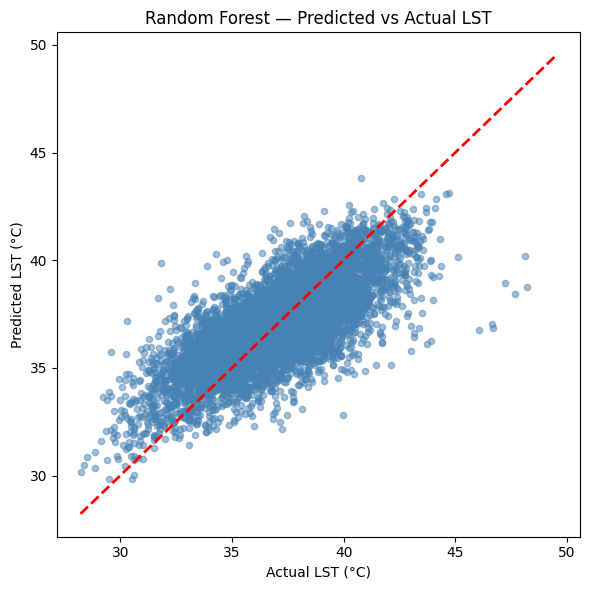

Saved → predicted_vs_actual.png


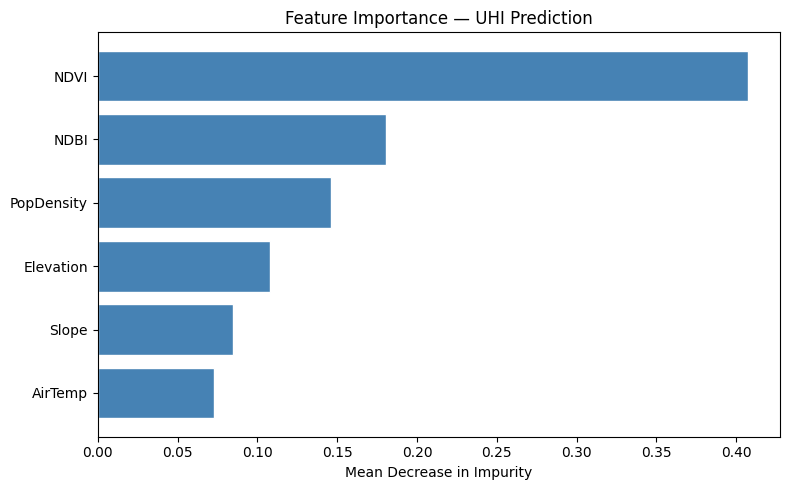

Saved → feature_importance.png


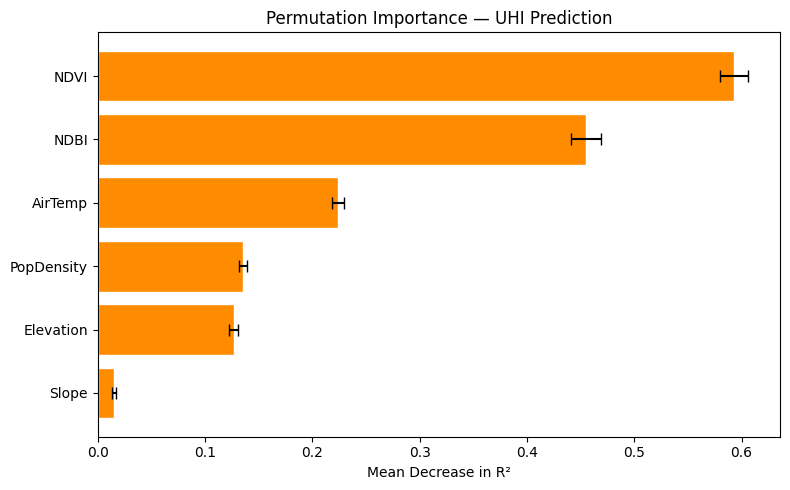

Saved → permutation_importance.png


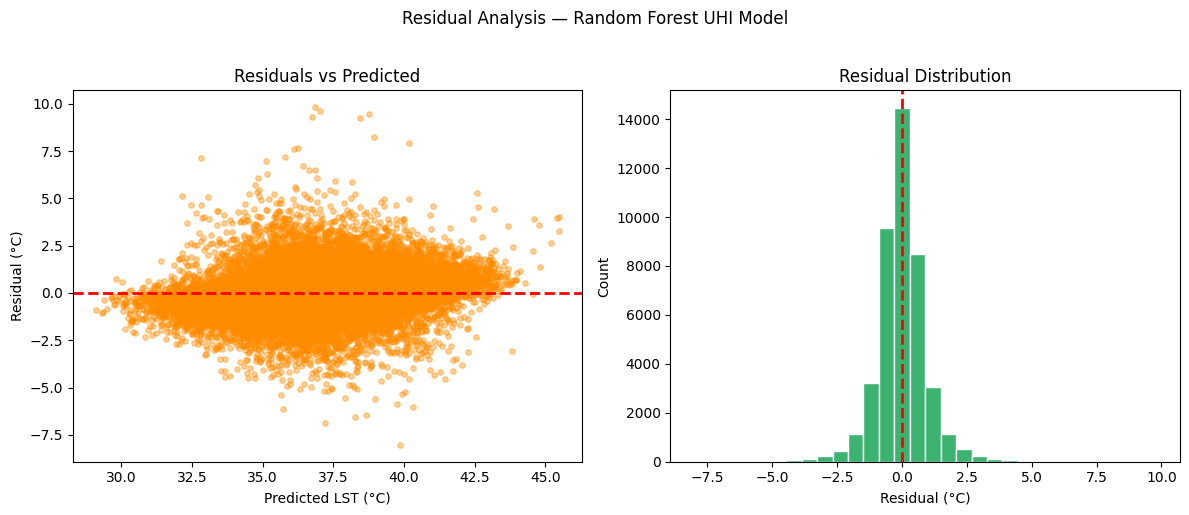

Saved → residual_analysis.png

UHI Zone Distribution:
UHI_Zone
Moderate Zone     8579
Mild Zone         8579
Warm Zone         8579
Hot Zone (UHI)    8579
Cool Zone         8579
Name: count, dtype: int64


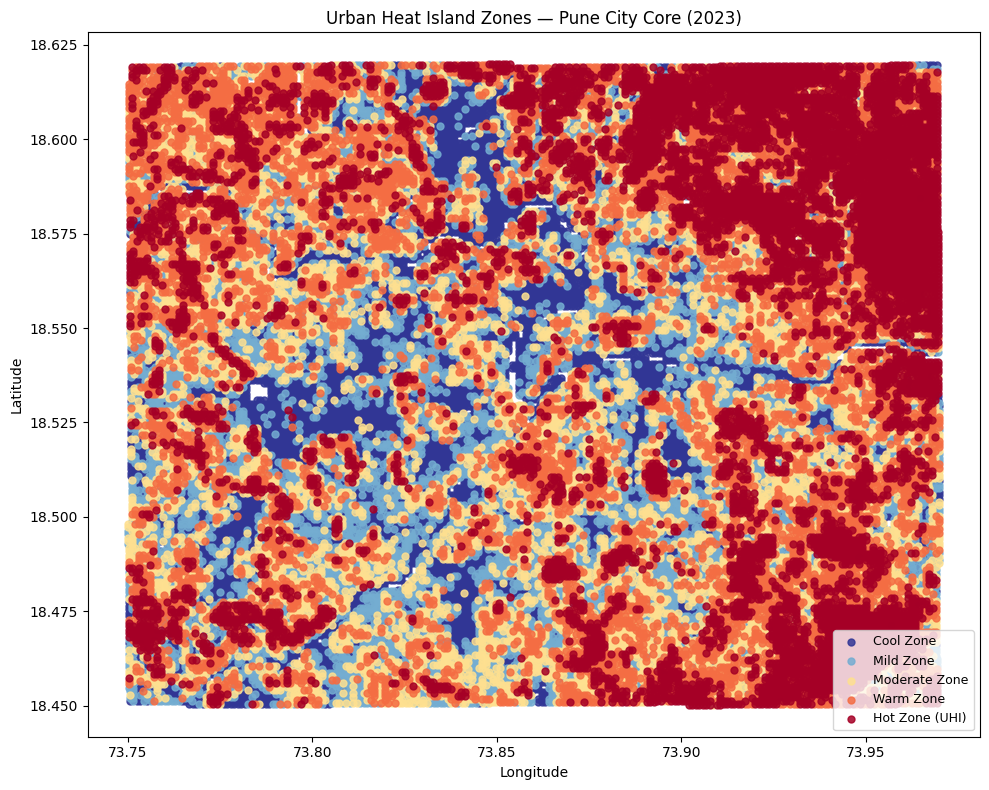

Saved → uhi_zone_map.png


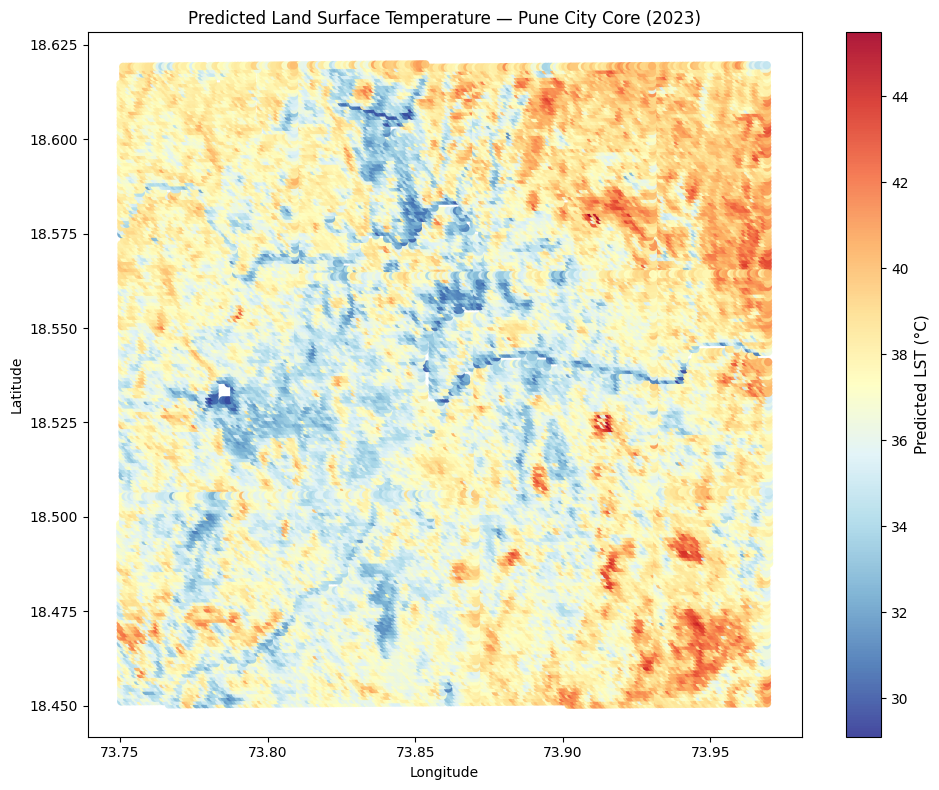

Saved → uhi_lst_continuous.png
Saved → uhi_heatmap.html
Saved → uhi_zone_map.html
Saved → UHI_Final_Predictions.csv

  COMPLETE PIPELINE SUMMARY
  Grid cells     : 42895
  Features used  : ['NDVI', 'NDBI', 'AirTemp', 'Elevation', 'Slope', 'PopDensity']
  R² (test)      : 0.5353
  RMSE           : 1.6574 °C
  LST range      : 29.11 – 45.49 °C
  Hottest cell   : Lat 18.5795, Lon 73.9125, 45.49 °C
  Coolest zone   : Cool Zone

✅ Full pipeline complete. All files saved.


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import folium
from folium.plugins import HeatMap
import joblib

# ============================================================
# 1. LOAD AND CLEAN
# ============================================================

df = pd.read_csv('UrbanHeatDataset.csv')
df.drop(columns=['.geo', 'system:index'], inplace=True, errors='ignore')
df.dropna(inplace=True)

print(f"✅ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

FEATURES = ['NDVI', 'NDBI', 'AirTemp', 'Elevation',
            'Slope', 'PopDensity']
TARGET   = 'LST'

X = df[FEATURES]
y = df[TARGET]

print(f"   Features : {FEATURES}")
print(f"   Target   : {TARGET}")
print(f"   LST range: {y.min():.2f} – {y.max():.2f} °C")

# ============================================================
# 2. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n   Train: {X_train.shape[0]} rows")
print(f"   Test : {X_test.shape[0]} rows")

# ============================================================
# 3. TRAIN RANDOM FOREST
# ============================================================

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=4,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
joblib.dump(rf, 'uhi_rf_model.pkl')
print("\n✅ Random Forest trained and saved")

# ============================================================
# 4. EVALUATION
# ============================================================

y_pred_test = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae  = mean_absolute_error(y_test, y_pred_test)
r2   = r2_score(y_test, y_pred_test)

cv_scores = cross_val_score(rf, X, y, cv=5,
                             scoring='r2', n_jobs=-1)

print("\n" + "="*45)
print("  MODEL EVALUATION (Test Set)")
print("="*45)
print(f"  R²        : {r2:.4f}")
print(f"  RMSE      : {rmse:.4f} °C")
print(f"  MAE       : {mae:.4f} °C")
print(f"  CV R² (5) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("="*45)

# ============================================================
# 5. PREDICTED vs ACTUAL PLOT
# ============================================================

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test,
            alpha=0.5, s=20, color='steelblue')
plt.plot([y.min(), y.max()],
         [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual LST (°C)')
plt.ylabel('Predicted LST (°C)')
plt.title('Random Forest — Predicted vs Actual LST')
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → predicted_vs_actual.png")

# ============================================================
# 6. FEATURE IMPORTANCE
# ============================================================

importances = rf.feature_importances_
feat_df = pd.DataFrame({
    'Feature'    : FEATURES,
    'Importance' : importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'],
         color='steelblue', edgecolor='white')
plt.xlabel('Mean Decrease in Impurity')
plt.title('Feature Importance — UHI Prediction')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → feature_importance.png")

# ============================================================
# 7. PERMUTATION IMPORTANCE
# ============================================================

perm = permutation_importance(rf, X_test, y_test,
                               n_repeats=30,
                               random_state=42,
                               n_jobs=-1)
perm_df = pd.DataFrame({
    'Feature' : FEATURES,
    'Mean'    : perm.importances_mean,
    'Std'     : perm.importances_std
}).sort_values('Mean', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(perm_df['Feature'], perm_df['Mean'],
         xerr=perm_df['Std'],
         color='darkorange', edgecolor='white', capsize=4)
plt.xlabel('Mean Decrease in R²')
plt.title('Permutation Importance — UHI Prediction')
plt.tight_layout()
plt.savefig('permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → permutation_importance.png")

# ============================================================
# 8. RESIDUAL ANALYSIS
# ============================================================

y_pred_all = rf.predict(X)
residuals  = y - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_pred_all, residuals,
                alpha=0.4, s=15, color='darkorange')
axes[0].axhline(0, color='red', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted LST (°C)')
axes[0].set_ylabel('Residual (°C)')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=30,
             color='mediumseagreen', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual (°C)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

plt.suptitle('Residual Analysis — Random Forest UHI Model', y=1.02)
plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → residual_analysis.png")

# ============================================================
# 9. UHI ZONE CLASSIFICATION
# ============================================================

df['LST_Predicted'] = y_pred_all
df['LST_Actual']    = y.values
df['Residual']      = residuals.values

p20 = df['LST_Predicted'].quantile(0.20)
p40 = df['LST_Predicted'].quantile(0.40)
p60 = df['LST_Predicted'].quantile(0.60)
p80 = df['LST_Predicted'].quantile(0.80)

def classify_uhi(lst):
    if lst <= p20:   return 'Cool Zone'
    elif lst <= p40: return 'Mild Zone'
    elif lst <= p60: return 'Moderate Zone'
    elif lst <= p80: return 'Warm Zone'
    else:            return 'Hot Zone (UHI)'

df['UHI_Zone'] = df['LST_Predicted'].apply(classify_uhi)

print("\nUHI Zone Distribution:")
print(df['UHI_Zone'].value_counts())

zone_colors = {
    'Cool Zone'      : '#313695',
    'Mild Zone'      : '#74add1',
    'Moderate Zone'  : '#fee090',
    'Warm Zone'      : '#f46d43',
    'Hot Zone (UHI)' : '#a50026'
}

# ============================================================
# 10. STATIC ZONE MAP
# ============================================================

plt.figure(figsize=(10, 8))
for zone, color in zone_colors.items():
    subset = df[df['UHI_Zone'] == zone]
    plt.scatter(subset['longitude'], subset['latitude'],
                c=color, label=zone, s=25, alpha=0.85)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Urban Heat Island Zones — Pune City Core (2023)')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('uhi_zone_map.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved → uhi_zone_map.png")

# ============================================================
# 11. CONTINUOUS LST MAP
# ============================================================

plt.figure(figsize=(10, 8))
sc = plt.scatter(df['longitude'], df['latitude'],
                 c=df['LST_Predicted'],
                 cmap='RdYlBu_r', s=25, alpha=0.9)
cbar = plt.colorbar(sc)
cbar.set_label('Predicted LST (°C)', fontsize=11)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Predicted Land Surface Temperature — Pune City Core (2023)')
plt.tight_layout()
plt.savefig('uhi_lst_continuous.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved → uhi_lst_continuous.png")

# ============================================================
# 12. INTERACTIVE FOLIUM MAPS
# ============================================================

center_lat = df['latitude'].mean()
center_lon = df['longitude'].mean()

# Map A — Heatmap
m1 = folium.Map(location=[center_lat, center_lon],
                zoom_start=13, tiles='CartoDB positron')
heat_data = [[r['latitude'], r['longitude'], r['LST_Predicted']]
             for _, r in df.iterrows()]
HeatMap(heat_data, min_opacity=0.4,
        radius=20, blur=12).add_to(m1)
m1.save('uhi_heatmap.html')
print("Saved → uhi_heatmap.html")

# Map B — Zone markers
m2 = folium.Map(location=[center_lat, center_lon],
                zoom_start=13, tiles='OpenStreetMap')
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=6,
        color=None,
        fill=True,
        fill_color=zone_colors[row['UHI_Zone']],
        fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>Zone:</b> {row['UHI_Zone']}<br>"
            f"<b>LST:</b> {row['LST_Predicted']:.2f} °C<br>"
            f"<b>NDBI:</b> {row['NDBI']:.3f}<br>"
            f"<b>NDVI:</b> {row['NDVI']:.3f}<br>"
            f"<b>PopDensity:</b> {row['PopDensity']:.1f}",
            max_width=200)
    ).add_to(m2)

legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:14px; border-radius:8px;
     border:2px solid #aaa; font-size:13px; line-height:24px;">
  <b>UHI Zone</b><br>
  <span style="color:#313695;font-size:18px;">&#9632;</span> Cool Zone<br>
  <span style="color:#74add1;font-size:18px;">&#9632;</span> Mild Zone<br>
  <span style="color:#fee090;font-size:18px;">&#9632;</span> Moderate Zone<br>
  <span style="color:#f46d43;font-size:18px;">&#9632;</span> Warm Zone<br>
  <span style="color:#a50026;font-size:18px;">&#9632;</span> Hot Zone (UHI)<br>
</div>
"""
m2.get_root().html.add_child(folium.Element(legend_html))
m2.save('uhi_zone_map.html')
print("Saved → uhi_zone_map.html")

# ============================================================
# 13. EXPORT FINAL CSV
# ============================================================

out_cols = ['latitude', 'longitude'] + FEATURES + \
           ['LST_Actual', 'LST_Predicted', 'Residual', 'UHI_Zone']
df[out_cols].to_csv('UHI_Final_Predictions.csv', index=False)
print("Saved → UHI_Final_Predictions.csv")

# ============================================================
# SUMMARY
# ============================================================

print("\n" + "="*45)
print("  COMPLETE PIPELINE SUMMARY")
print("="*45)
print(f"  Grid cells     : {len(df)}")
print(f"  Features used  : {FEATURES}")
print(f"  R² (test)      : {r2:.4f}")
print(f"  RMSE           : {rmse:.4f} °C")
print(f"  LST range      : {df['LST_Predicted'].min():.2f}"
      f" – {df['LST_Predicted'].max():.2f} °C")
hottest = df.nlargest(1, 'LST_Predicted')[
    ['latitude','longitude','LST_Predicted','UHI_Zone']].values[0]
print(f"  Hottest cell   : Lat {hottest[0]:.4f}, "
      f"Lon {hottest[1]:.4f}, {hottest[2]:.2f} °C")
print(f"  Coolest zone   : {df.nsmallest(1,'LST_Predicted')['UHI_Zone'].values[0]}")
print("="*45)
print("\n✅ Full pipeline complete. All files saved.")

In [69]:
import pandas as pd

df = pd.read_csv('UrbanHeatDataset.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nCoordinate range:")
print(df[['latitude','longitude']].describe())

Shape: (42895, 14)
Columns: ['system:index', 'AirTemp', 'Elevation', 'LST', 'NDBI', 'NDVI', 'NDWI', 'PopDensity', 'Slope', 'WindSpeed', 'grid_id', 'latitude', 'longitude', '.geo']

Coordinate range:
           latitude     longitude
count  42895.000000  42895.000000
mean      18.534772     73.860105
std        0.049074      0.063607
min       18.450229     73.750097
25%       18.492151     73.805007
50%       18.534346     73.860200
75%       18.577479     73.915281
max       18.619832     73.969901


Rows loaded: 42895
Zone distribution:
UHI_Zone
Warm Zone         8579
Moderate Zone     8579
Hot Zone (UHI)    8579
Mild Zone         8579
Cool Zone         8579
Name: count, dtype: int64


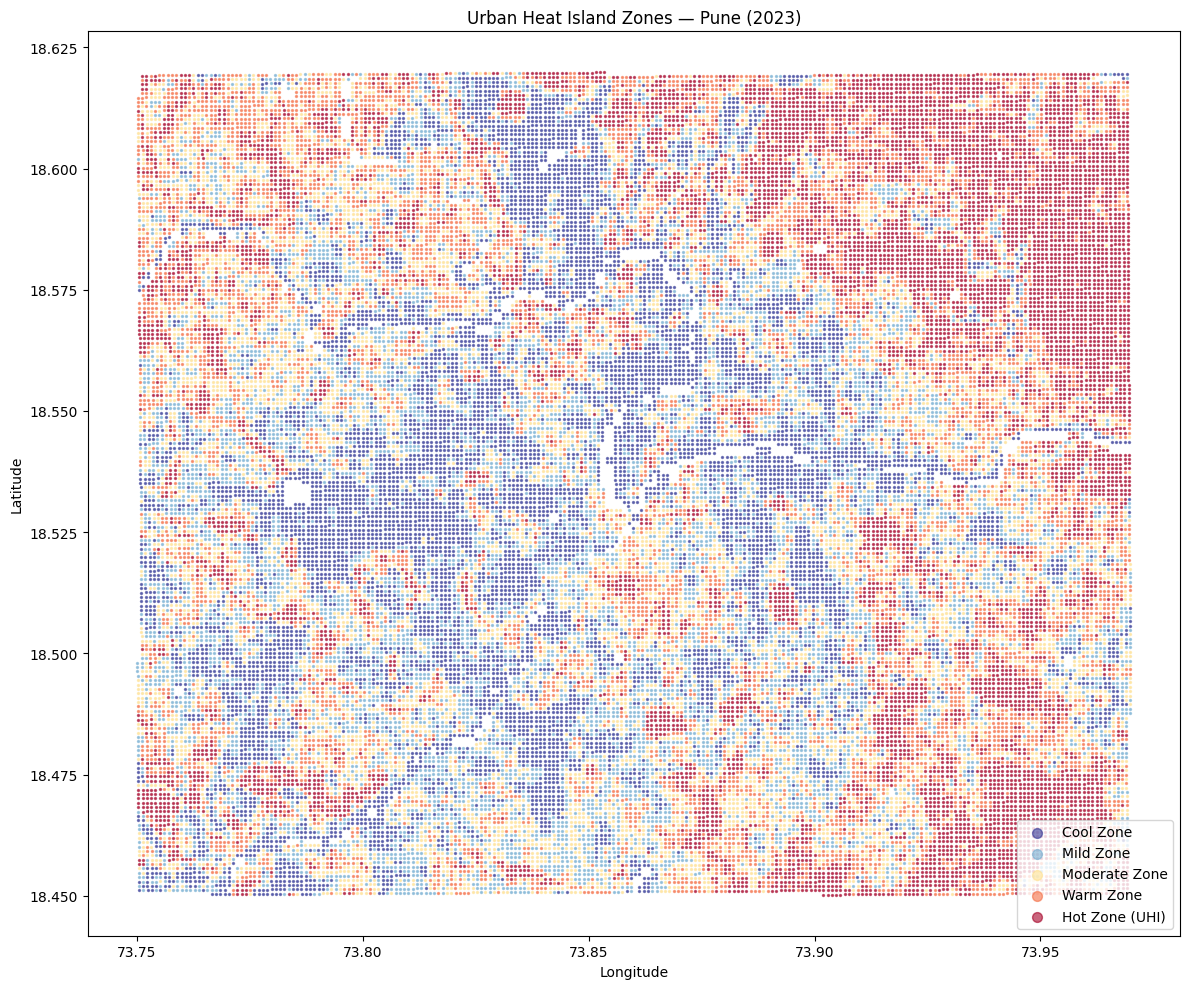

Saved → uhi_zone_map.png
Saved → uhi_heatmap.html
✅ Saved → uhi_zone_map.html
   Open in Chrome or Edge browser
Saved → uhi_satellite_map.html

✅ All maps saved. Open in browser:
   → uhi_heatmap.html
   → uhi_zone_map.html
   → uhi_satellite_map.html
   → uhi_zone_map.png  (static)


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.ensemble import RandomForestRegressor
import folium
from folium.plugins import HeatMap
import joblib

# ============================================================
# 1. LOAD NEW CSV
# ============================================================

df = pd.read_csv('UrbanHeatDataset.csv')
df.drop(columns=['.geo', 'system:index'], inplace=True, errors='ignore')
df.dropna(inplace=True)

print(f"Rows loaded: {len(df)}")

FEATURES = ['NDVI', 'NDBI', 'AirTemp', 'Elevation', 'Slope', 'PopDensity']
TARGET   = 'LST'

X = df[FEATURES]
y = df[TARGET]

# ============================================================
# 2. TRAIN & PREDICT
# ============================================================

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X, y)
joblib.dump(rf, 'uhi_rf_model.pkl')

df['LST_Predicted'] = rf.predict(X)

# ============================================================
# 3. UHI ZONES
# ============================================================

p20 = df['LST_Predicted'].quantile(0.20)
p40 = df['LST_Predicted'].quantile(0.40)
p60 = df['LST_Predicted'].quantile(0.60)
p80 = df['LST_Predicted'].quantile(0.80)

def classify_uhi(lst):
    if lst <= p20:   return 'Cool Zone'
    elif lst <= p40: return 'Mild Zone'
    elif lst <= p60: return 'Moderate Zone'
    elif lst <= p80: return 'Warm Zone'
    else:            return 'Hot Zone (UHI)'

df['UHI_Zone'] = df['LST_Predicted'].apply(classify_uhi)

zone_colors = {
    'Cool Zone'      : '#313695',
    'Mild Zone'      : '#74add1',
    'Moderate Zone'  : '#fee090',
    'Warm Zone'      : '#f46d43',
    'Hot Zone (UHI)' : '#a50026'
}

print("Zone distribution:")
print(df['UHI_Zone'].value_counts())

# ============================================================
# 4. STATIC MATPLOTLIB MAP
# ============================================================

plt.figure(figsize=(12, 10))
for zone, color in zone_colors.items():
    subset = df[df['UHI_Zone'] == zone]
    plt.scatter(subset['longitude'], subset['latitude'],
                c=color, label=zone, s=2, alpha=0.6)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Urban Heat Island Zones — Pune (2023)')
plt.legend(loc='lower right', markerscale=5)
plt.tight_layout()
plt.savefig('uhi_zone_map.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved → uhi_zone_map.png")

# ============================================================
# 5. HEATMAP (sampled — folium can't handle 42k points well)
# ============================================================

# Sample 5000 points for folium performance
df_sample = df.sample(n=5000, random_state=42)

center_lat = df['latitude'].mean()
center_lon = df['longitude'].mean()

m1 = folium.Map(location=[center_lat, center_lon],
                zoom_start=12, tiles='CartoDB positron')

heat_data = [[r['latitude'], r['longitude'], r['LST_Predicted']]
             for _, r in df_sample.iterrows()]

HeatMap(heat_data, min_opacity=0.5,
        radius=15, blur=10).add_to(m1)

m1.save('uhi_heatmap.html')
print("Saved → uhi_heatmap.html")

# ============================================================
# 6. INTERACTIVE ZONE MAP (sampled)
# ============================================================

import folium
import json

zone_colors = {
    'Cool Zone'      : '#313695',
    'Mild Zone'      : '#74add1',
    'Moderate Zone'  : '#fee090',
    'Warm Zone'      : '#f46d43',
    'Hot Zone (UHI)' : '#a50026'
}

center_lat = df['latitude'].mean()
center_lon = df['longitude'].mean()

# Sample 2000 points only
df_sample = df.sample(n=2000, random_state=42)

# Build GeoJSON
features = []
for _, row in df_sample.iterrows():
    features.append({
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [row['longitude'], row['latitude']]
        },
        "properties": {
            "zone"  : row['UHI_Zone'],
            "lst"   : round(row['LST_Predicted'], 2),
            "ndbi"  : round(row['NDBI'], 3),
            "ndvi"  : round(row['NDVI'], 3),
            "color" : zone_colors[row['UHI_Zone']]
        }
    })

geojson = {"type": "FeatureCollection", "features": features}

m = folium.Map(location=[center_lat, center_lon],
               zoom_start=12, tiles='OpenStreetMap')

folium.GeoJson(
    geojson,
    marker=folium.CircleMarker(radius=4),
    style_function=lambda f: {
        'color'       : f['properties']['color'],
        'fillColor'   : f['properties']['color'],
        'fillOpacity' : 0.8,
        'weight'      : 0
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['zone', 'lst', 'ndbi', 'ndvi'],
        aliases=['Zone:', 'LST (°C):', 'NDBI:', 'NDVI:']
    )
).add_to(m)

legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:14px; border-radius:8px;
     border:2px solid #aaa; font-size:13px; line-height:24px;">
  <b>UHI Zone</b><br>
  <span style="color:#313695;font-size:18px;">&#9632;</span> Cool Zone<br>
  <span style="color:#74add1;font-size:18px;">&#9632;</span> Mild Zone<br>
  <span style="color:#fee090;font-size:18px;">&#9632;</span> Moderate Zone<br>
  <span style="color:#f46d43;font-size:18px;">&#9632;</span> Warm Zone<br>
  <span style="color:#a50026;font-size:18px;">&#9632;</span> Hot Zone (UHI)<br>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
m.save('uhi_zone_map.html')
print("✅ Saved → uhi_zone_map.html")
print("   Open in Chrome or Edge browser")

# ============================================================
# 7. SATELLITE MAP
# ============================================================

m3 = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12,
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri Satellite')

lst_min = df['LST_Predicted'].min()
lst_max = df['LST_Predicted'].max()
cmap    = cm.get_cmap('RdYlBu_r')

for _, row in df_sample.iterrows():
    norm_val  = (row['LST_Predicted'] - lst_min) / (lst_max - lst_min)
    hex_color = mcolors.to_hex(cmap(norm_val))
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        color=None,
        fill=True,
        fill_color=hex_color,
        fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>LST:</b> {row['LST_Predicted']:.2f} °C<br>"
            f"<b>Zone:</b> {row['UHI_Zone']}",
            max_width=150)
    ).add_to(m3)

m3.save('uhi_satellite_map.html')
print("Saved → uhi_satellite_map.html")

print("\n✅ All maps saved. Open in browser:")
print("   → uhi_heatmap.html")
print("   → uhi_zone_map.html")
print("   → uhi_satellite_map.html")
print("   → uhi_zone_map.png  (static)")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

# ============================================================
# 1. LOAD MODEL AND DATA
# ============================================================

rf = joblib.load('uhi_rf_model.pkl')

df = pd.read_csv('UrbanHeatDataset.csv')
df.drop(columns=['.geo', 'system:index'], inplace=True, errors='ignore')
df.dropna(inplace=True)

FEATURES = ['NDVI', 'NDBI', 'AirTemp', 'Elevation', 'Slope', 'PopDensity']
X = df[FEATURES]

# Sample 2000 rows for speed (SHAP is slow on 42k rows)
X_sample = X.sample(n=2000, random_state=42)

# ============================================================
# 2. COMPUTE SHAP VALUES
# ============================================================

print("Computing SHAP values... (may take 2-3 mins)")
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

print("✅ SHAP values computed")

# ============================================================
# 3. SHAP SUMMARY BEESWARM PLOT
# ============================================================

plt.figure()
shap.summary_plot(shap_values, X_sample,
                  plot_type='dot', show=False)
plt.title('SHAP Summary — What Drives Urban Heat in Pune?')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → shap_summary.png")

# ============================================================
# 4. SHAP BAR PLOT
# ============================================================

plt.figure()
shap.summary_plot(shap_values, X_sample,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance — UHI Drivers')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → shap_importance.png")

# ============================================================
# 5. SHAP DEPENDENCE PLOTS
# ============================================================

for feat in ['AirTemp', 'NDBI', 'NDVI', 'Elevation']:
    idx = FEATURES.index(feat)
    plt.figure()
    shap.dependence_plot(idx, shap_values, X_sample,
                         feature_names=FEATURES, show=False)
    plt.title(f'SHAP Dependence — {feat} vs LST Impact')
    plt.tight_layout()
    plt.savefig(f'shap_dependence_{feat}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → shap_dependence_{feat}.png")

# ============================================================
# 6. SHAP MEAN TABLE
# ============================================================

shap_mean = pd.DataFrame(
    shap_values, columns=FEATURES
).abs().mean().sort_val

Computing SHAP values... (may take 2-3 mins)
